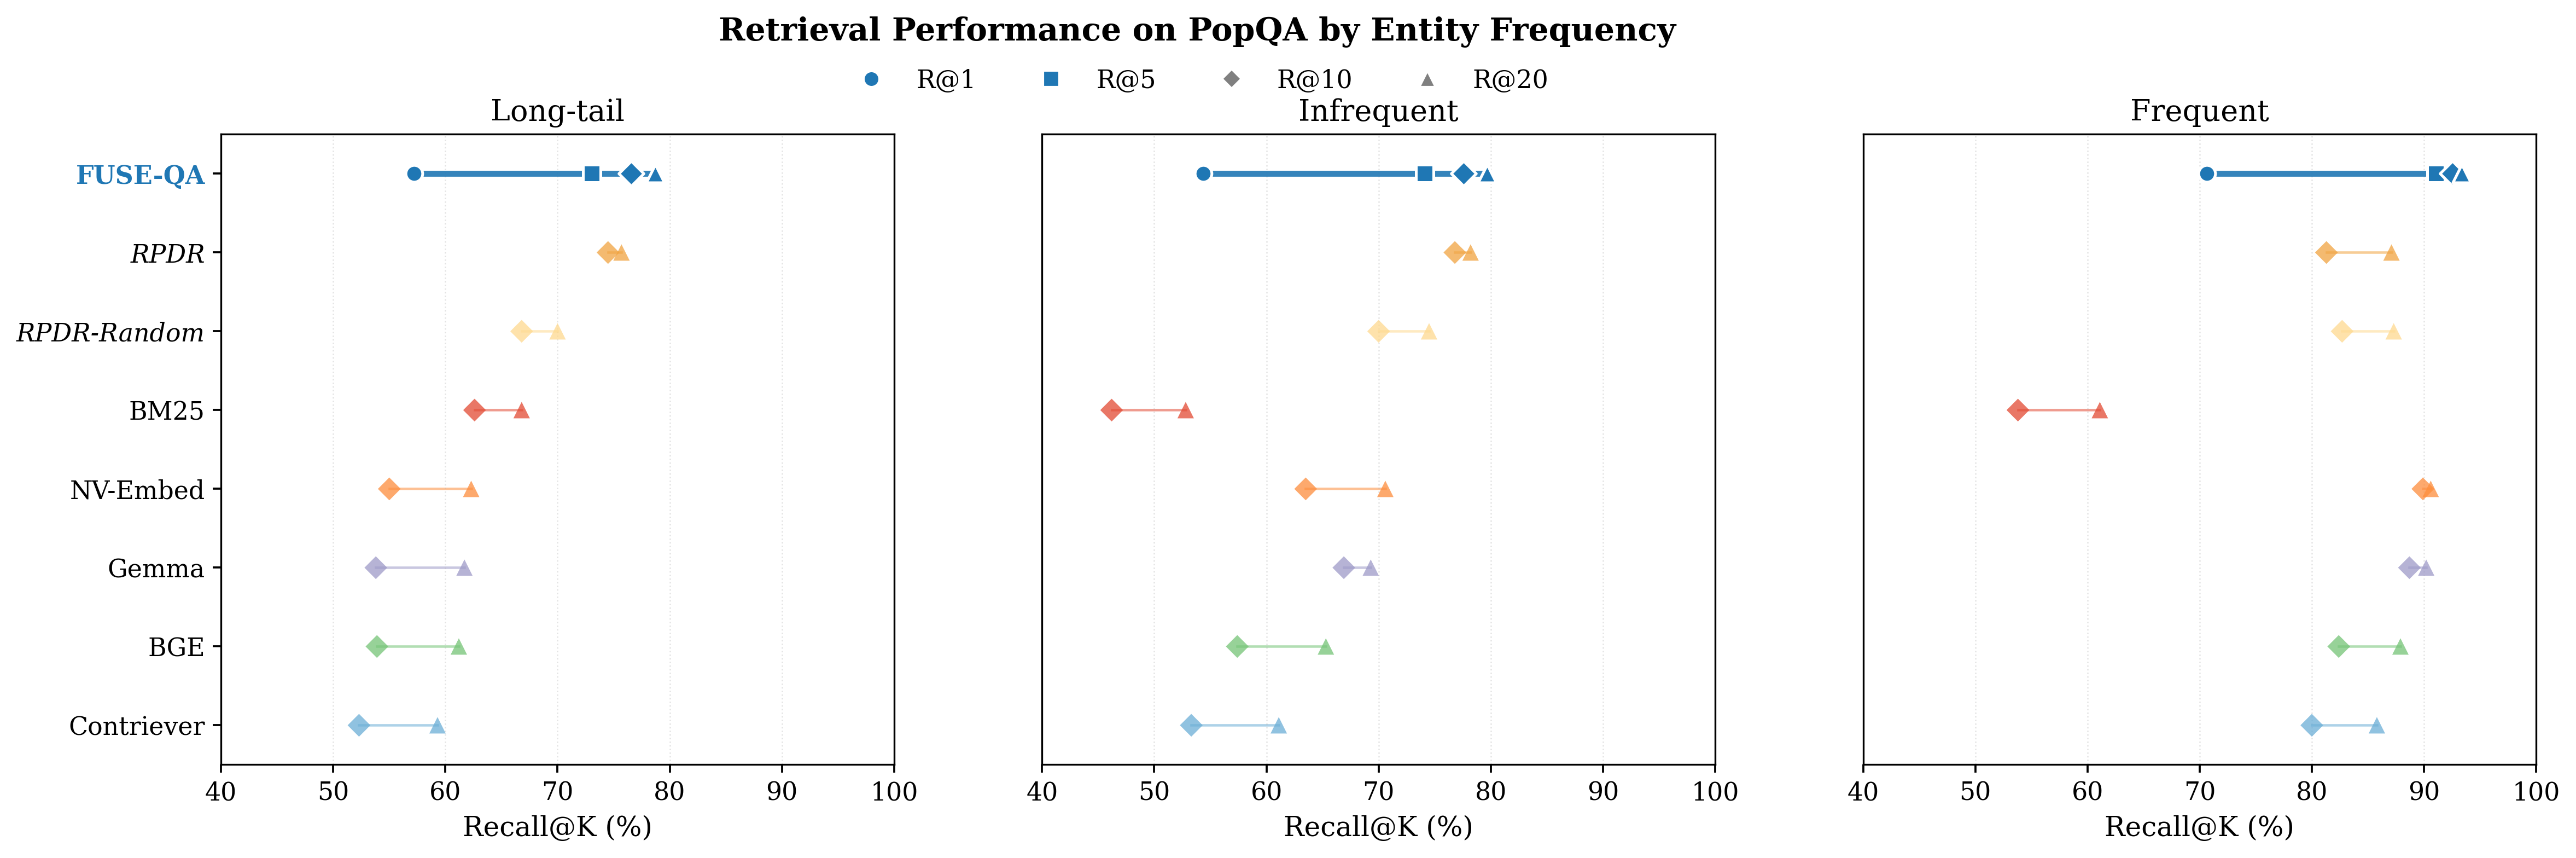

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# -------------------------------------------------
# Data
# -------------------------------------------------
methods = [
    "BM25", "Contriever", "BGE", "NV-Embed",
    "Gemma", "RPDR", "RPDR-Random", "FUSE-QA (ours)"
]

data = {
    "Long-tail": {
        "BM25": {"R@10": 62.6, "R@20": 66.8},
        "Contriever": {"R@10": 52.3, "R@20": 59.3},
        "BGE": {"R@10": 53.9, "R@20": 61.2},
        "NV-Embed": {"R@10": 55.0, "R@20": 62.3},
        "Gemma": {"R@10": 53.8, "R@20": 61.7},
        "RPDR": {"R@10": 74.5, "R@20": 75.7},
        "RPDR-Random": {"R@10": 66.8, "R@20": 70.0},
        "FUSE-QA (ours)": {"R@1": 57.18, "R@5": 73.05, "R@10": 76.55, "R@20": 78.70},
    },
    "Infrequent": {
        "BM25": {"R@10": 46.2, "R@20": 52.8},
        "Contriever": {"R@10": 53.3, "R@20": 61.1},
        "BGE": {"R@10": 57.4, "R@20": 65.3},
        "NV-Embed": {"R@10": 63.5, "R@20": 70.6},
        "Gemma": {"R@10": 66.9, "R@20": 69.3},
        "RPDR": {"R@10": 76.8, "R@20": 78.2},
        "RPDR-Random": {"R@10": 70.0, "R@20": 74.5},
        "FUSE-QA (ours)": {"R@1": 54.36, "R@5": 74.09, "R@10": 77.57, "R@20": 79.66},
    },
    "Frequent": {
        "BM25": {"R@10": 53.8, "R@20": 61.1},
        "Contriever": {"R@10": 80.0, "R@20": 85.8},
        "BGE": {"R@10": 82.4, "R@20": 87.9},
        "NV-Embed": {"R@10": 89.9, "R@20": 90.6},
        "Gemma": {"R@10": 88.7, "R@20": 90.2},
        "RPDR": {"R@10": 81.3, "R@20": 87.1},
        "RPDR-Random": {"R@10": 82.7, "R@20": 87.3},
        "FUSE-QA (ours)": {"R@1": 70.62, "R@5": 91.06, "R@10": 92.55, "R@20": 93.36},
    },
}

tiers = ["Long-tail", "Infrequent", "Frequent"]

sorted_methods = sorted(
    methods,
    key=lambda m: data["Long-tail"][m].get("R@20", 0),
    reverse=True
)

# -------------------------------------------------
# Style (publication grade)
# -------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

colors = {
    "BM25": "#E24A33",
    "Contriever": "#6BAED6",
    "BGE": "#74C476",
    "NV-Embed": "#FD8D3C",
    "Gemma": "#9E9AC8",
    "RPDR": "#F1A340",
    "RPDR-Random": "#FED98F",
    "FUSE-QA (ours)": "#1F77B4",
}

markers = {
    "R@1":  {"marker": "o", "size": 45},
    "R@5":  {"marker": "s", "size": 48},
    "R@10": {"marker": "D", "size": 50},
    "R@20": {"marker": "^", "size": 52},
}

# -------------------------------------------------
# Figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(17, 6))
gs = gridspec.GridSpec(
    1, 3,
    figure=fig,
    wspace=0.22
)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

fig.subplots_adjust(
    left=0.15,
    right=0.98,
    top=0.86,
    bottom=0.22
)

# -------------------------------------------------
# Plot
# -------------------------------------------------
for tier_index, (ax, tier) in enumerate(zip(axes, tiers)):

    y = np.arange(len(sorted_methods))

    for i, method in enumerate(sorted_methods):

        values = data[tier][method]

        r1 = values.get("R@1")
        r5 = values.get("R@5")
        r10 = values.get("R@10")
        r20 = values.get("R@20")

        pts = []
        if r1: pts.append(("R@1", r1))
        if r5: pts.append(("R@5", r5))
        if r10: pts.append(("R@10", r10))
        if r20: pts.append(("R@20", r20))

        pts = sorted(pts, key=lambda x: x[1])

        xs = [p[1] for p in pts]

        is_ours = method == "FUSE-QA (ours)"
        color = colors[method]

        if len(xs) > 1:
            if is_ours:
                ax.plot(
                    xs,
                    [i]*len(xs),
                    color=color,
                    linewidth=2.6,
                    alpha=0.9,
                    zorder=2
                )
            else:
                ax.plot(
                    xs,
                    [i]*len(xs),
                    color=color,
                    linewidth=1.1,
                    alpha=0.55,
                    zorder=1
                )

        for metric, val in pts:

            style = markers[metric]

            if is_ours:
                ax.scatter(
                    val,
                    i,
                    s=style["size"]*1.2,
                    marker=style["marker"],
                    color=color,
                    edgecolors="white",
                    linewidths=1.2,
                    zorder=5
                )
            else:
                ax.scatter(
                    val,
                    i,
                    s=style["size"],
                    marker=style["marker"],
                    color=color,
                    alpha=0.75,
                    edgecolors="none",
                    zorder=3
                )

    ax.set_xlim(40, 100)
    ax.set_ylim(-0.5, len(sorted_methods)-0.5)
    ax.invert_yaxis()

    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.6,
        alpha=0.35
    )

    ax.set_xticks([40,50,60,70,80,90,100])
    ax.set_xlabel("Recall@K (%)")

    if tier_index == 0:

        ax.set_yticks(y)

        labels = [m.replace(" (ours)", "") for m in sorted_methods]

        ax.set_yticklabels(labels)

        for lbl, m in zip(ax.get_yticklabels(), sorted_methods):

            if m == "FUSE-QA (ours)":
                lbl.set_fontweight("bold")
                lbl.set_color(colors[m])

            elif "RPDR" in m:
                lbl.set_fontstyle("italic")

    else:
        ax.set_yticks([])

    ax.set_title(tier)

# -------------------------------------------------
# Legend
# -------------------------------------------------
legend_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#1F77B4", label="R@1", markersize=7),
    Line2D([0],[0], marker="s", color="w", markerfacecolor="#1F77B4", label="R@5", markersize=7),
    Line2D([0],[0], marker="D", color="w", markerfacecolor="gray", label="R@10", markersize=6),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="gray", label="R@20", markersize=7),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5,0.95)
)

# -------------------------------------------------
# Title
# -------------------------------------------------
fig.suptitle(
    "Retrieval Performance on PopQA by Entity Frequency",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

# -------------------------------------------------
# Save
# -------------------------------------------------
plt.savefig(
    "fuseqa_popqa_recall.pdf",
    bbox_inches="tight",
    format="pdf"
)

plt.savefig(
    "fuseqa_popqa_recall.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()